<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter05_02_%EC%BA%90%EA%B8%80%EC%A3%BC%ED%83%9D%EA%B0%80%EA%B2%A9_%ED%9A%8C%EA%B7%80%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


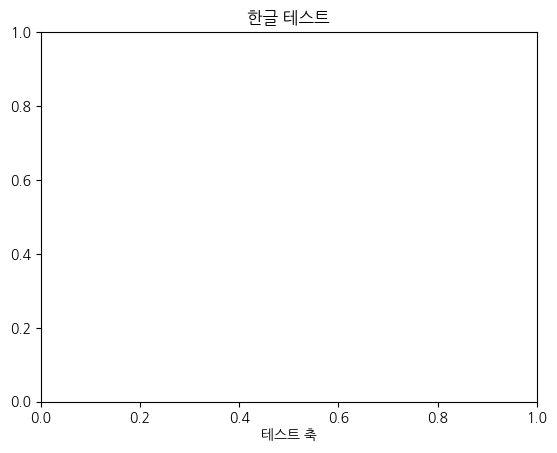

In [1]:
# 구글 드라이브 마운트
from google.colab import drive, files
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew


import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor # XGBoost 회귀용 클래스
from lightgbm import LGBMRegressor # LightGBM 회귀용 클래스

In [3]:
# 데이터 로딩 및 기본 탐색 (EDA)

# 캐글 House Prices 데이터셋, 미국 아이오와주 에임스(Ames) 지역 주택 거래 데이터
house_df_org = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/house_prices/train-2.csv')

house_df = house_df_org.copy()

print('데이터 크기:', house_df.shape) # id + 79개 피처 + ScalePrice
print('\n피처 타입 분포:')
print(house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print('\n결측치 많은 컬럼 (상위 10개):')
print(isnull_series[isnull_series > 0].sort_values(ascending=False).head(10))

데이터 크기: (1460, 81)

피처 타입 분포:
object     43
int64      35
float64     3
Name: count, dtype: int64

결측치 많은 컬럼 (상위 10개):
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


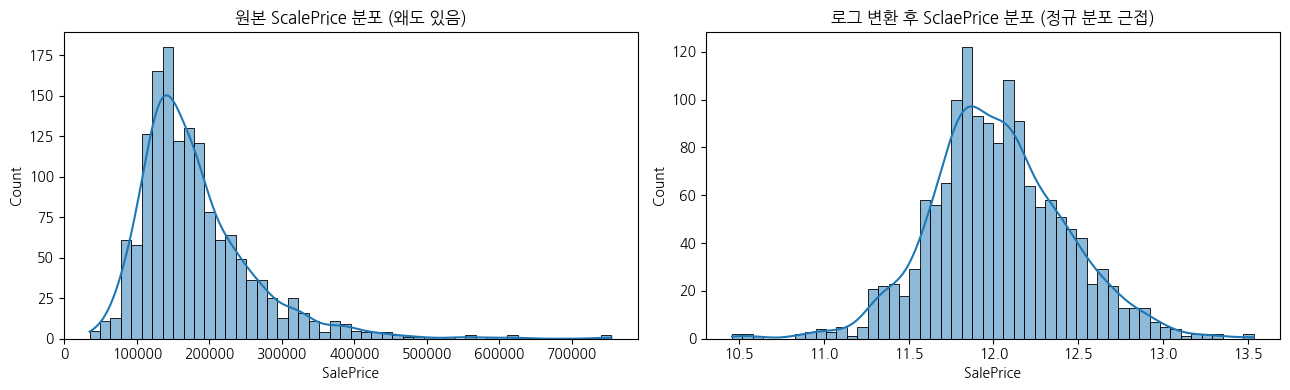

In [4]:
# ScalePrice 분포 확인 및 로그 변환 필요성 검토
# 선형 회귀는 종속변수 (ScalePrice)가 정규 분포에 가까울수록 성능 좋음
fig, axes = plt.subplots(1,2, figsize=(13, 4))

axes[0].set_title('원본 ScalePrice 분포 (왜도 있음)')
sns.histplot(house_df['SalePrice'], bins=50, kde=True, ax=axes[0])

axes[1].set_title('로그 변환 후 SclaePrice 분포 (정규 분포 근접)')
sns.histplot(np.log1p(house_df['SalePrice']), bins=50, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [5]:
# STEP 1: 전처리 - 로그 변환 + 결측치 처리 + 원-핫 인코딩
# [전처리 순서가 중요한 이유]
#   1. SalePrice 로그 변환 (모델 가정 충족)
#   2. 결측치 처리 (모델이 NaN 처리 못함)
#   3. 원-핫 인코딩 (문자형을 수치형으로 변환)

house_df['SalePrice'] = np.log1p(house_df['SalePrice'])
house_df.drop(
    ['Id', 'PoolQC','MiscFeature','Alley','Fence','FireplaceQu'],
    axis=1, inplace=True, errors='ignore'
)
numerical_cols = house_df.select_dtypes(include=np.number).columns
house_df[numerical_cols] = house_df[numerical_cols].fillna(house_df[numerical_cols].mean()) # 각 컬럼별로 평균값이 결측치로 대체

null_cols = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('남은 결측 컬럼 타입:\n', house_df.dtypes[null_cols.index])

남은 결측 컬럼 타입:
 MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
dtype: object


In [6]:
# STEP 2: 원-핫 인코딩(One-Hot Encoding)
# pd.get_dummies vs sklearn OneHotEncoder
# get_dummies는 결측값(NaN)을 0으로 처리, 전체 데이터를 한 번에 변환, 학습/테스트 분리 후 컬럼 수 불일치 주의
print('get_dummies() 전 shape:', house_df.shape)

house_df_ohe = pd.get_dummies(house_df)
print('get_dummies() 후 shape:', house_df_ohe.shape)
null_cols = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum() > 0]
print(len(null_cols))

get_dummies() 전 shape: (1460, 75)
get_dummies() 후 shape: (1460, 270)
0


In [7]:
# 선형 회귀 모델 학습/예측/평가

# 학습/테스트 분리
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)
print('학습셋:', X_train.shape, '테스트셋:', X_test.shape)

학습셋: (1168, 269) 테스트셋: (292, 269)


In [8]:
def get_rmse(model):
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  print(f"{model.__class__.__name__} RMSE: {rmse:.4f}")
  return rmse

def get_rmses(models):
  return [get_rmse(model) for model in models]

In [9]:
#LinearRegression , Ridge, Lasso 기본 학습
lr_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()

lr_reg.fit(X_train, y_train)
ridge_reg.fit(X_train, y_train)
lasso_reg.fit(X_train, y_train)

print('기본 하이퍼 파라미터 RMSE')
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

기본 하이퍼 파라미터 RMSE
LinearRegression RMSE: 0.1318
Ridge RMSE: 0.1274
Lasso RMSE: 0.1763


[np.float64(0.13183184688250701),
 np.float64(0.1274058283626616),
 np.float64(0.17628250556471403)]

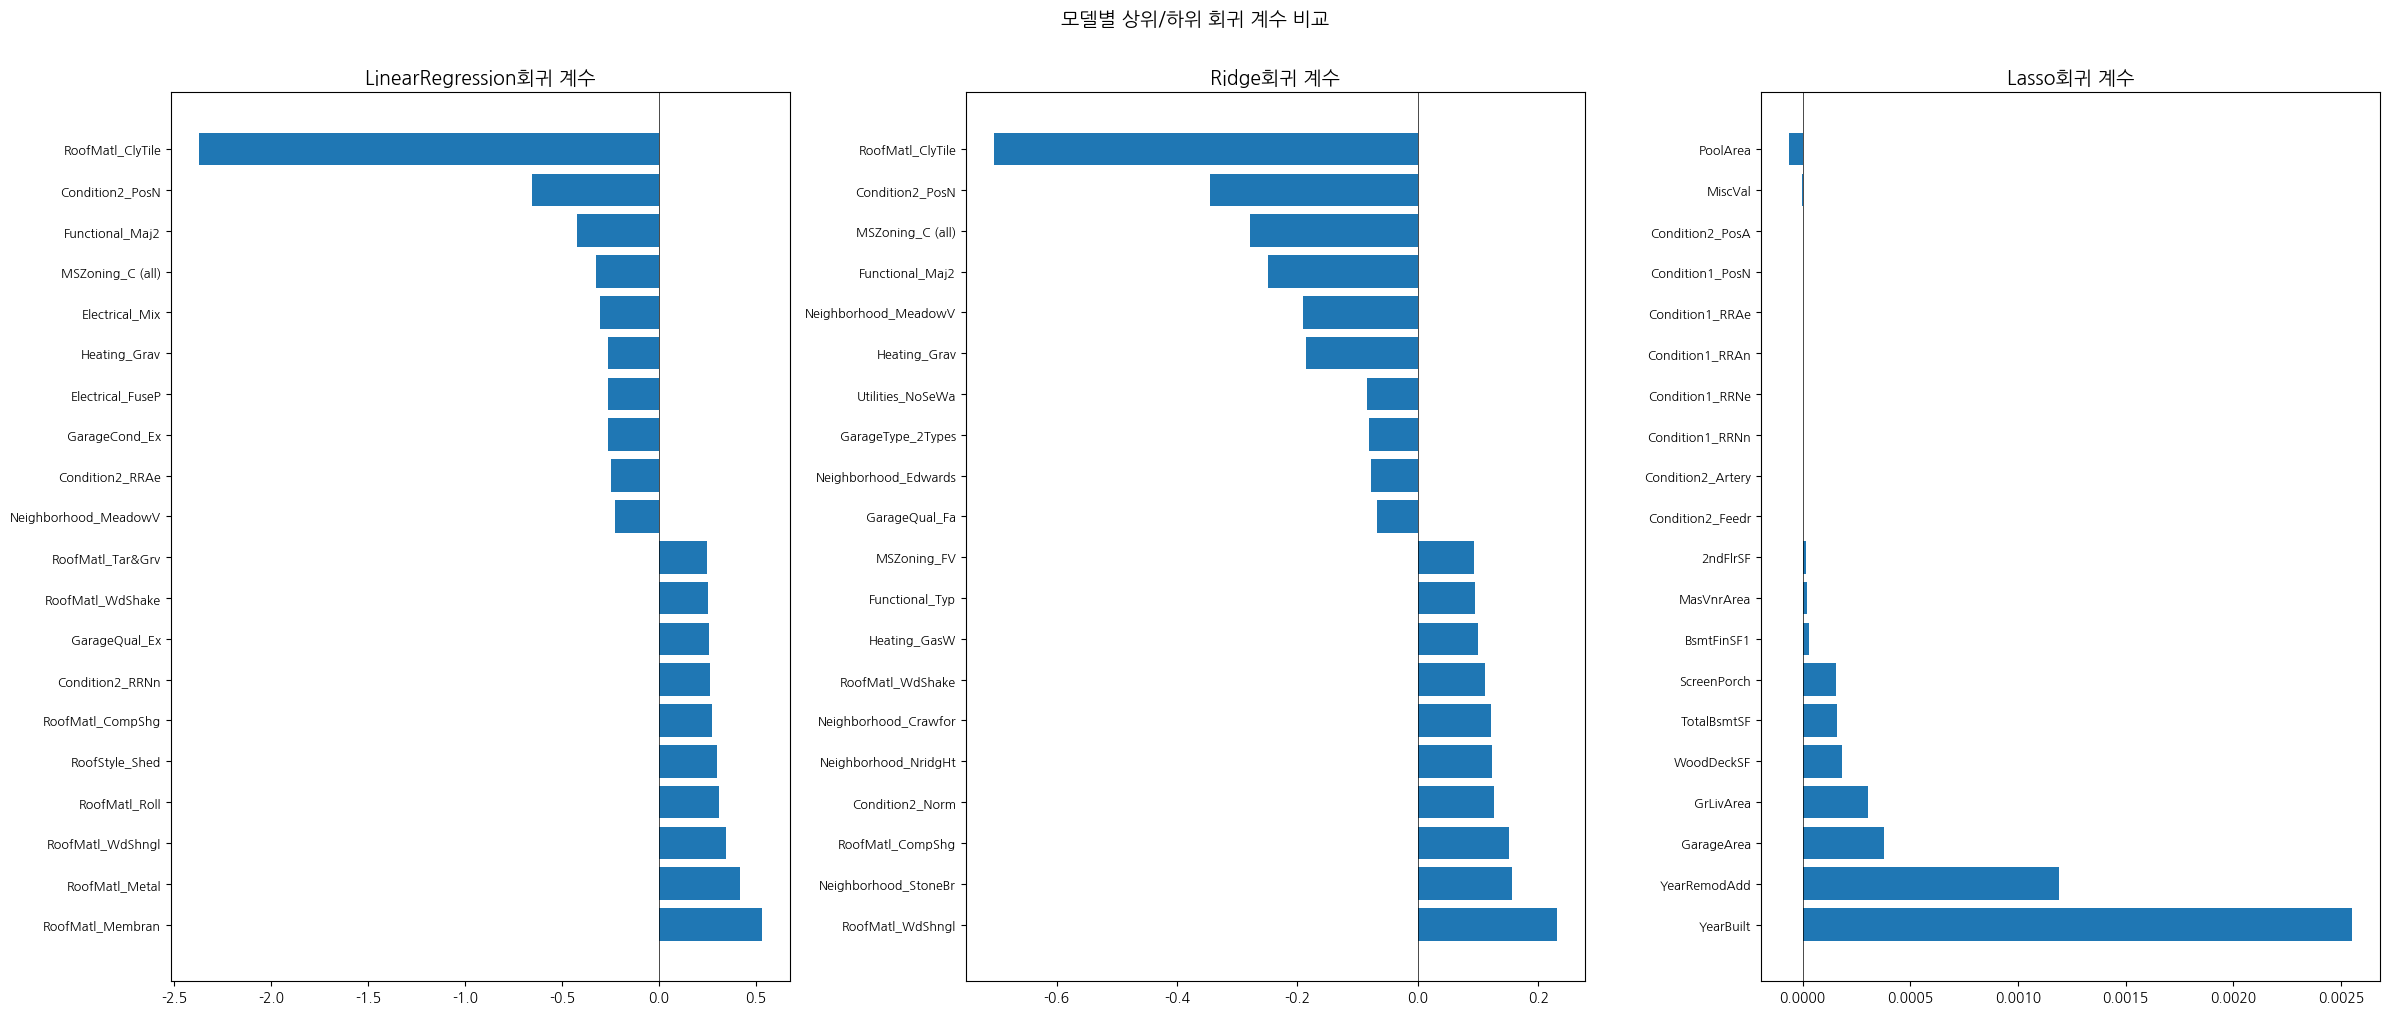

In [10]:
# 상위 10개(양의 영향) 하위 10개(음의 영향)회귀 계수 추출
def get_top_bottom_coef(model):
  coef = pd.Series(model.coef_, index=X_features.columns) # 각 컬럼의
  coef_high = coef.sort_values(ascending=False).head(10)
  coef_low = coef.sort_values(ascending=False).tail(10)
  return coef_high, coef_low

# 회귀 계수 시각화 함수
def visualize_coefficient(models):
  fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=3)
  for i, model in enumerate(models):
    coef_high, coef_low = get_top_bottom_coef(model)
    coef_concat = pd.concat([coef_high, coef_low]) # 하나의 Series로 합침
    axs[i].set_title(f'{model.__class__.__name__}회귀 계수', size=14)
    axs[i].tick_params(axis='y', labelsize=9)
    axs[i].barh(coef_concat.index, coef_concat.values)
    axs[i].axvline(0, color='black', linewidth=0.5)
  plt.suptitle('모델별 상위/하위 회귀 계수 비교', fontsize=14, y=1.01)
  fig.tight_layout()
  plt.show()

visualize_coefficient(models)

In [11]:
# 5-Fold 교차 검증 RMSE 비교
def get_avg_rmse_cv(models):
  for model in models:
    rmse_list = np.sqrt(-cross_val_score(
        model, X_features, y_target,
        scoring='neg_mean_squared_error',
        cv=5))
    print(f'{model.__class__.__name__} CV RMSE: {np.round(rmse_list, 43)} 평균: {np.round(np.mean(rmse_list), 3)}')



print('5-Fold 교착 검증 RMSE')
get_avg_rmse_cv([lr_reg, ridge_reg, lasso_reg])
# 5개 폴드 RMSE가 비슷하면 안정적, 차이가 크면 불안정한 모델

5-Fold 교착 검증 RMSE
LinearRegression CV RMSE: [0.13525294 0.16469768 0.16744808 0.11101817 0.19802657] 평균: 0.155
Ridge CV RMSE: [0.11723973 0.15443498 0.14210277 0.1165647  0.18901653] 평균: 0.144
Lasso CV RMSE: [0.16077499 0.20437243 0.17676683 0.18127643 0.2651206 ] 평균: 0.198


In [12]:
# GridSearchCV로 최적 alpha 탐색
ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]} #L1 규제는 계수를 0으로 만드는 힘 강함

def print_best_params(model, params):
  grid_model = GridSearchCV(
      model, param_grid=params,
      scoring='neg_mean_squared_error', cv=5
  )
  grid_model.fit(X_features, y_target)
  rmse = np.sqrt(-1 * grid_model.best_score_)
  print(f'{model.__class__.__name__} 5-CV 최적 RMSE: {rmse:.4f} 최적파라미터: {grid_model.best_params_}')
  return grid_model.best_estimator_ # 최적 파라미터로 학습된 모델 반환

best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.1418 최적파라미터: {'alpha': 12}
Lasso 5-CV 최적 RMSE: 0.1420 최적파라미터: {'alpha': 0.001}


[최적 alpha 적용 후] RMSE
LinearRegression RMSE: 0.1318
Ridge RMSE: 0.1241
Lasso RMSE: 0.1200


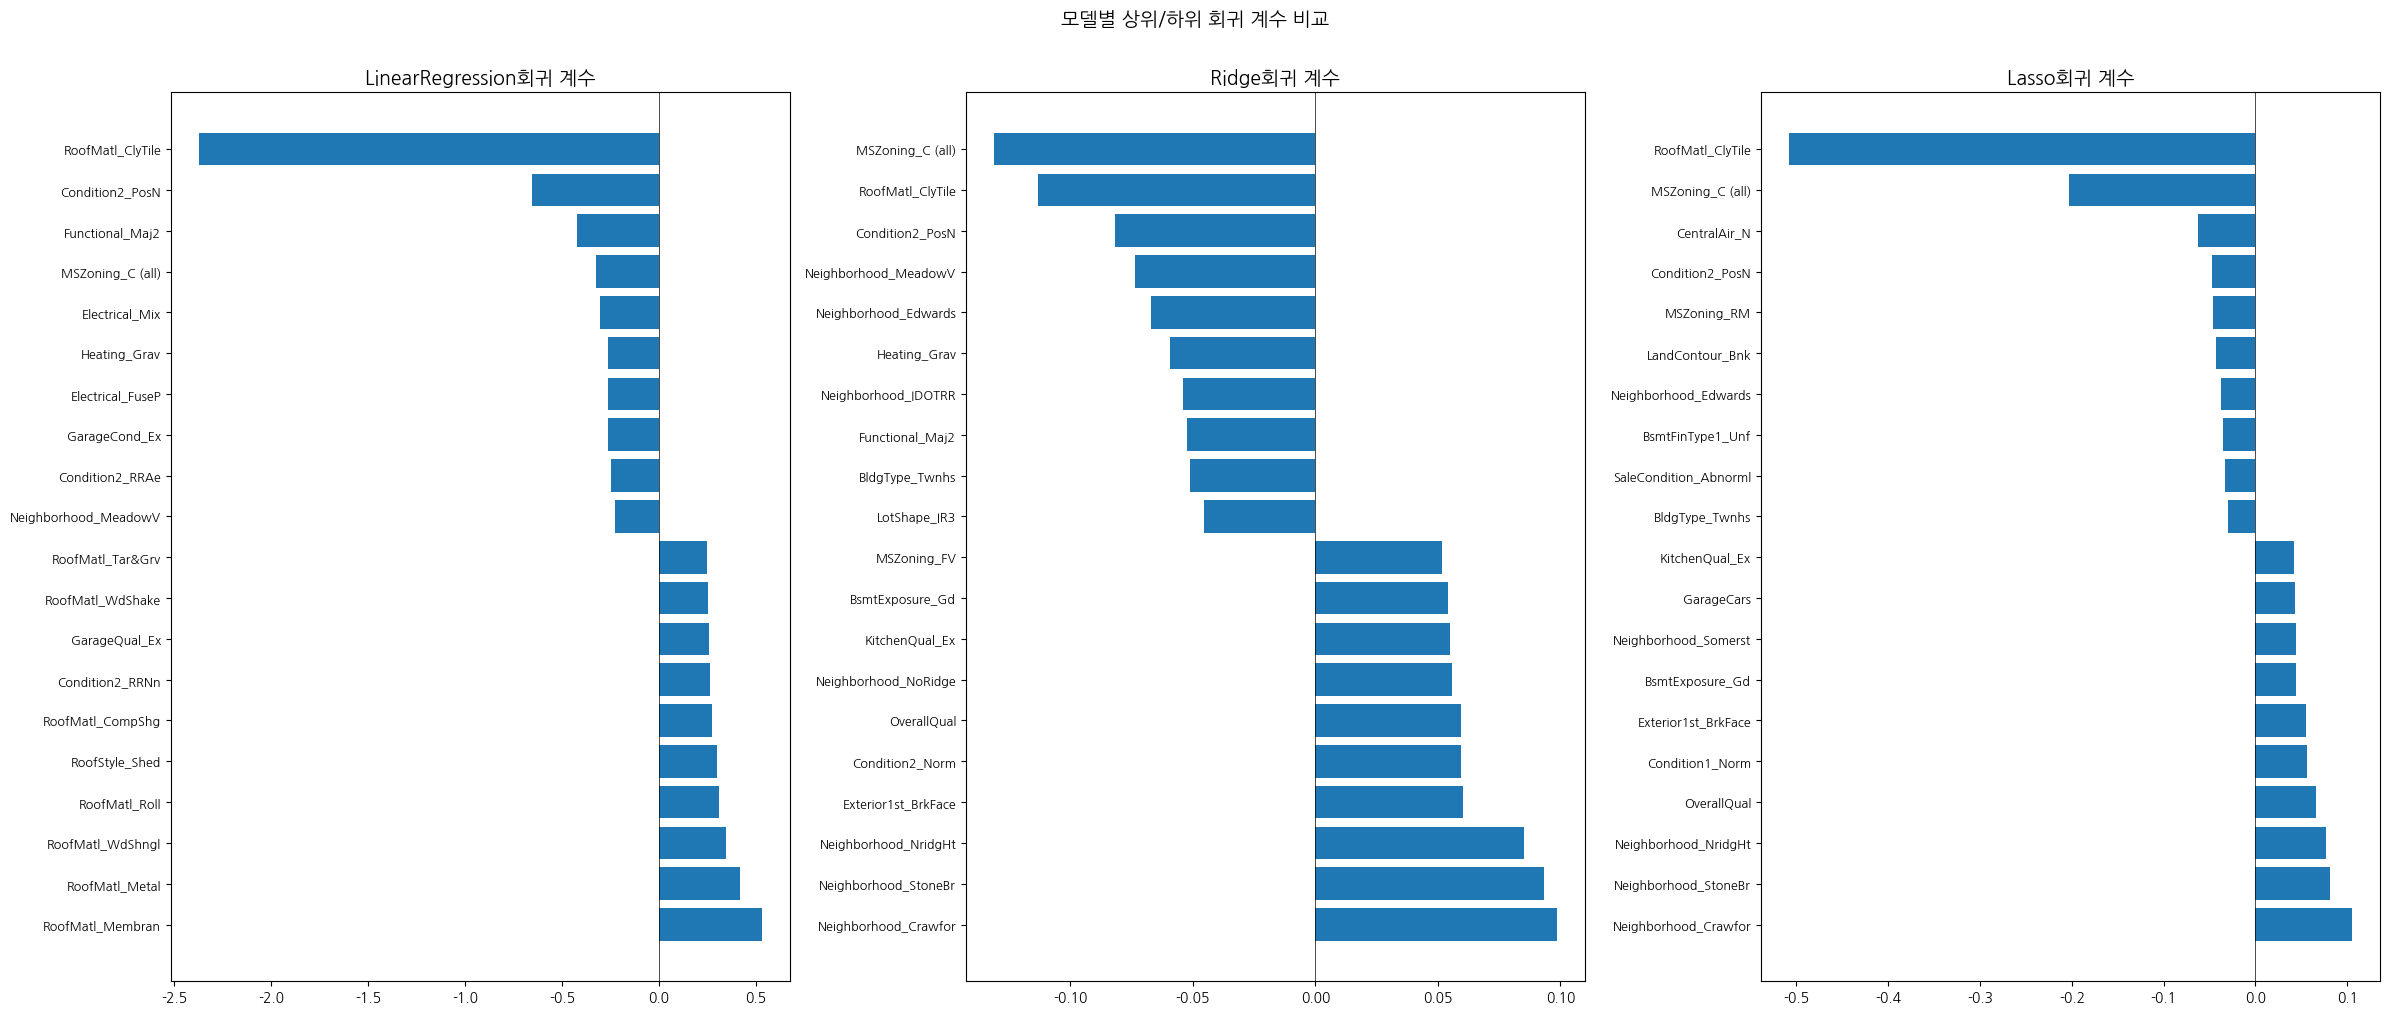

In [13]:
# 최적 alpha로 재학습 및 성능 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10) # 최적 alpha로 변경
lasso_reg = Lasso(alpha=0.001) # 최적 alpha로 변경

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)
print('[최적 alpha 적용 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg]) # get_rmse 대신 get_rmses 사용, set 대신 list 전달
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg]) # set 대신 list 전달

In [14]:
# 수치형 피처의 왜도 (Skewness) 분석
features_index = house_df.dtypes[house_df.dtypes != 'object'].index # 수치형 칼럼만 선택
skew_features = house_df[features_index].apply(lambda x: skew(x)) # 각 수치형 칼럼에 .skew() 적용
skew_features_top = skew_features[skew_features > 1]             # 왜도 1 이상인 피처만 필터링
print('왜도 > 1인 피처 목록 (내림차순): ')
print(skew_features_top.sort_values(ascending=False))

왜도 > 1인 피처 목록 (내림차순): 
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [15]:
# 왜도 높은 피처 로그 변환 후 전체 파이프라인 재실행
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])
house_df_ohe = pd.get_dummies(house_df) # 로그 변환 후 원-핫 인코딩 재적용

# 학습/테스트 분리 (동일 random_state로 공정 비교)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)

# 왜도 처리 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5-CV 최적 RMSE: 0.1275 최적파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.1252 최적파라미터: {'alpha': 0.001}


[왜도 처리 후] RMSE
LinearRegression RMSE: 0.1281
Ridge RMSE: 0.1225
Lasso RMSE: 0.1193


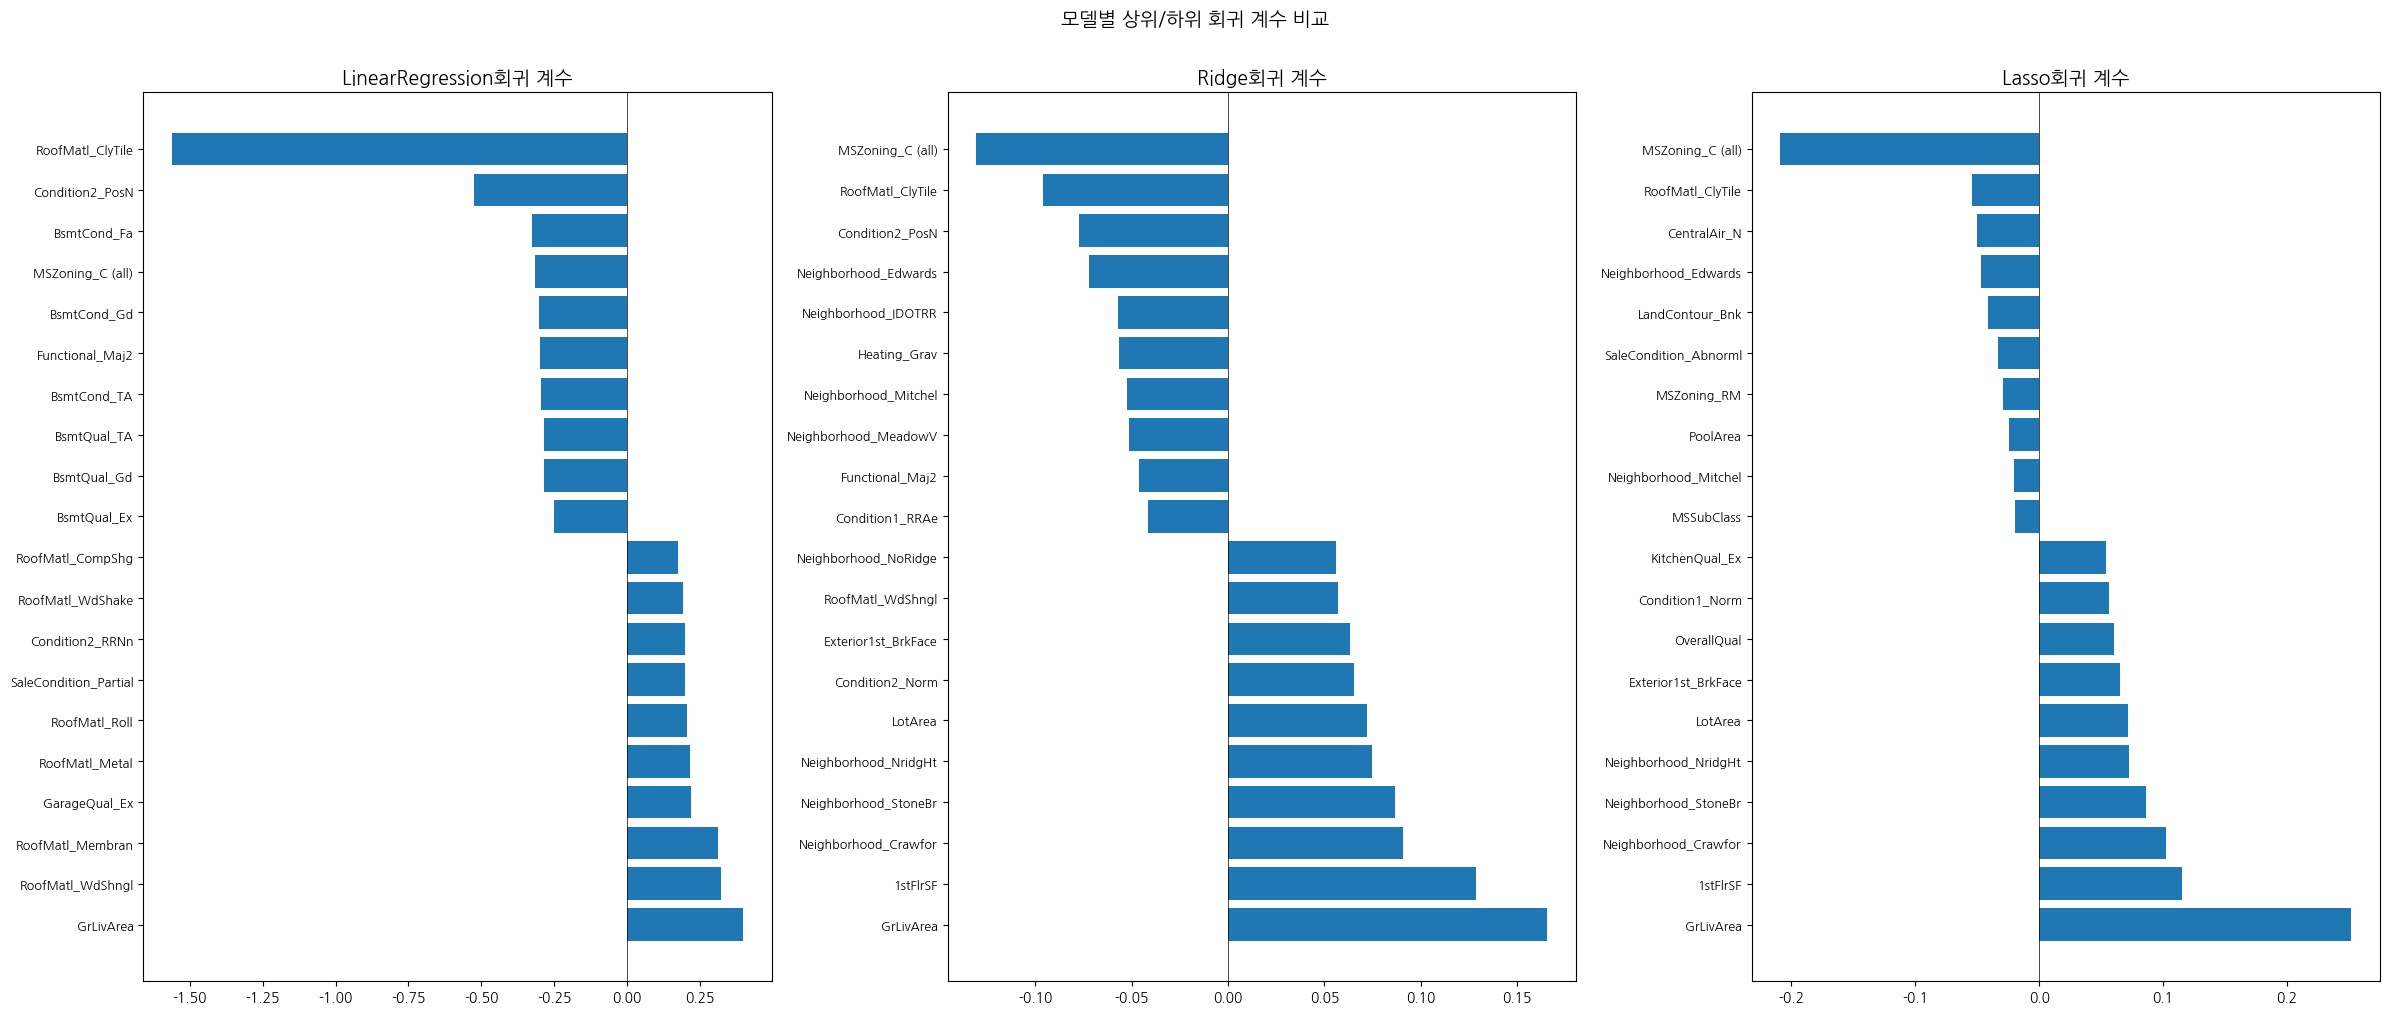

In [16]:
# 왜도 처리 후 최적 파라미터로 재학습 및 평가
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)
print('[왜도 처리 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg]) # set 대신 list 전달

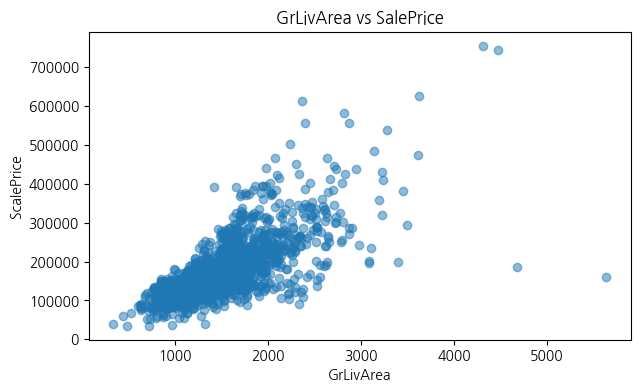

In [17]:
# 이상치(Outlier) 탐지: GrLivArea vs SalePrice 산점도
# 선형 회귀는 최소제곱법(MSE 최소화) -> 이상치에 민감, 이상치 하나가 회귀선 전체를 왜곡 가능
plt.figure(figsize=(7,4))
plt.scatter(
    x=house_df_org['GrLivArea'],
    y=house_df_org['SalePrice'],
    alpha=0.5
)
plt.ylabel('ScalePrice')
plt.xlabel('GrLivArea')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [18]:
# 이상치 제거
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(50000)
outlier_index = house_df_ohe[cond1 & cond2].index

print('이상치 레코드 인덱스:', outlier_index.values)
print('이상치 삭제 전:', house_df_ohe.shape)
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후:', house_df_ohe.shape)

이상치 레코드 인덱스: []
이상치 삭제 전: (1460, 270)
이상치 삭제 후: (1460, 270)


Ridge 5-CV 최적 RMSE: 0.1275 최적파라미터: {'alpha': 10}
Lasso 5-CV 최적 RMSE: 0.1252 최적파라미터: {'alpha': 0.001}
[이상치 제거 후] RMSE
LinearRegression RMSE: 0.1281
Ridge RMSE: 0.1225
Lasso RMSE: 0.1193


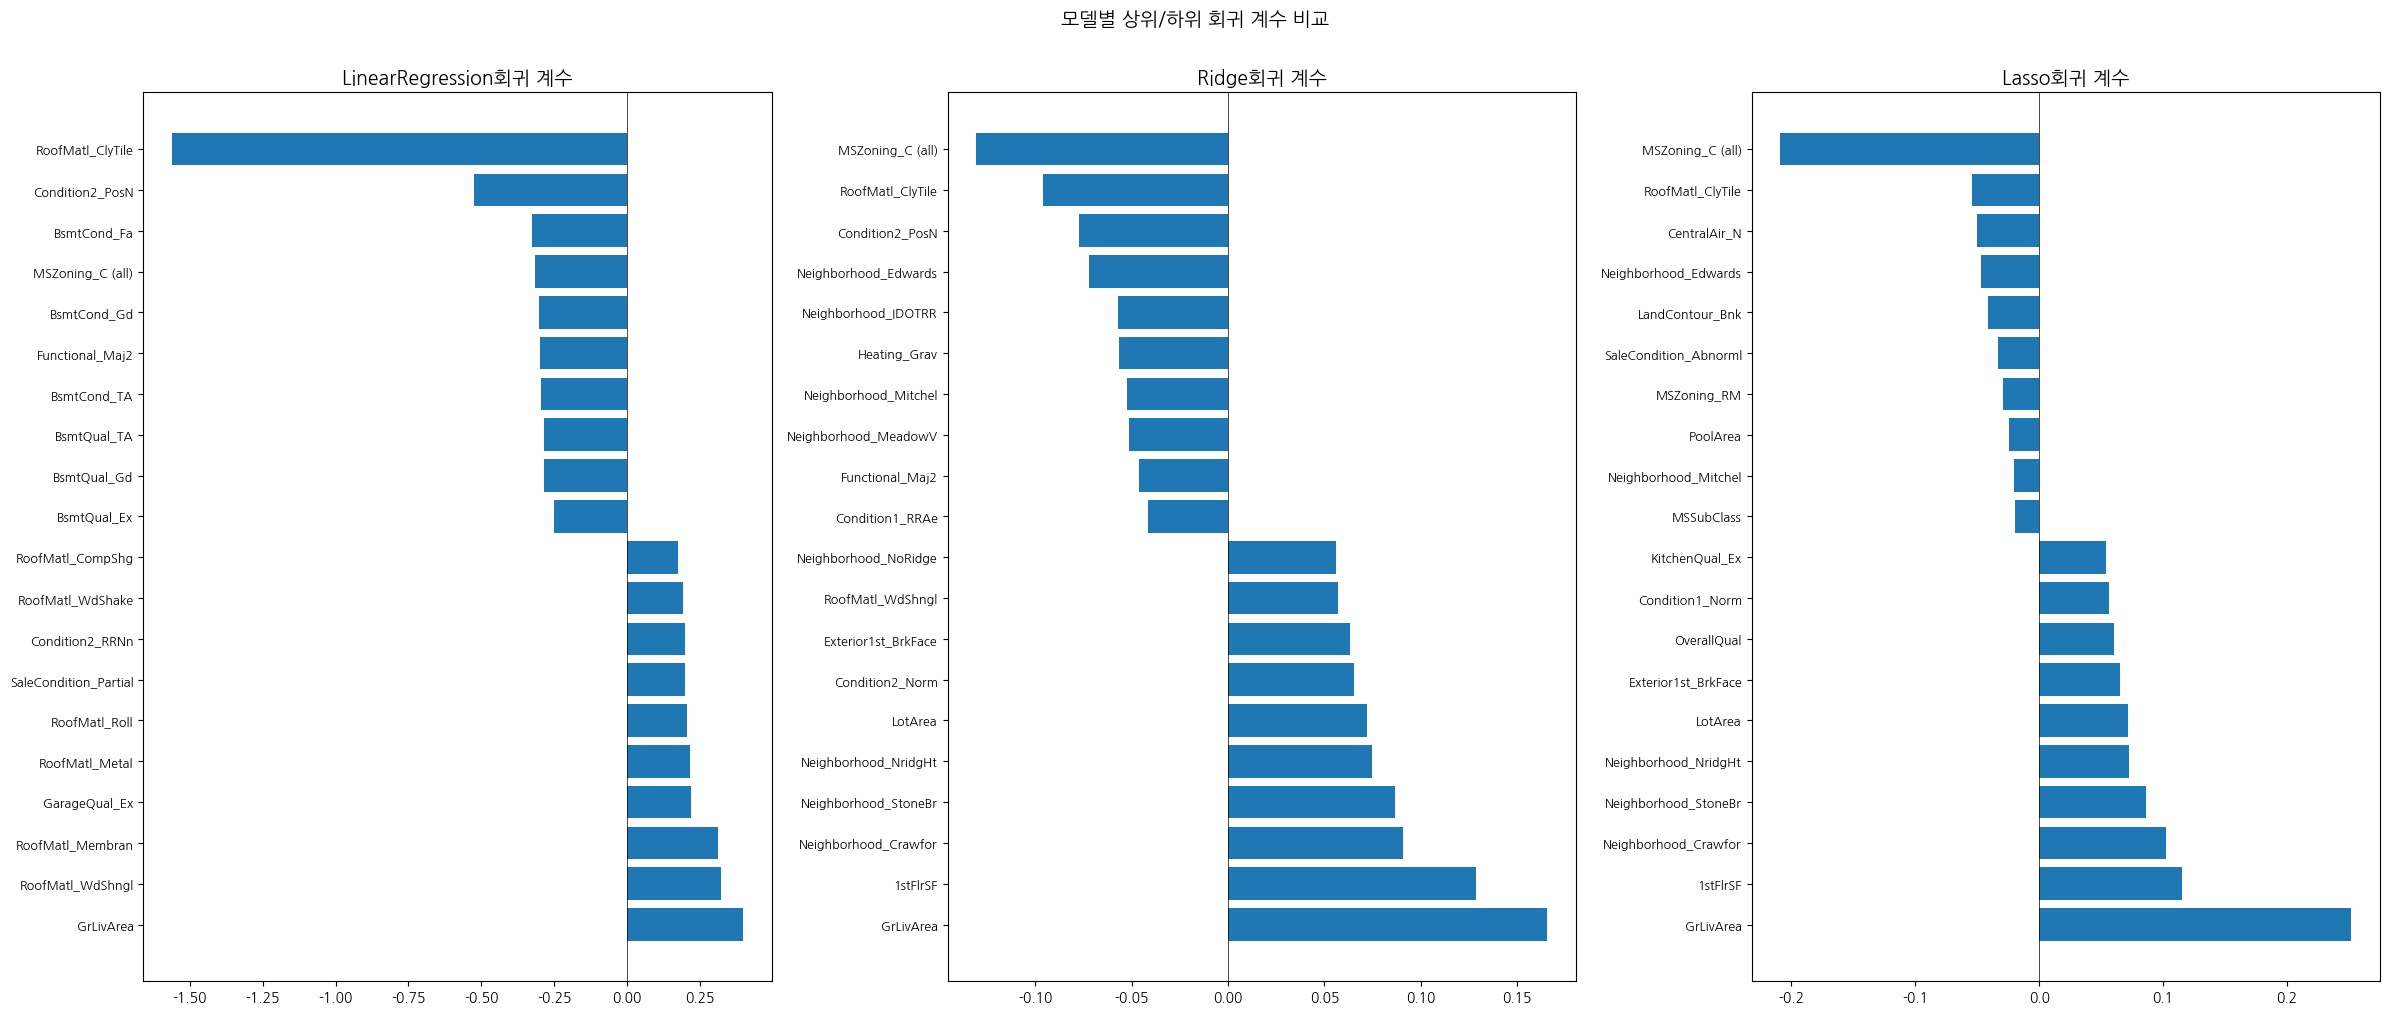

In [19]:
# 이상치 제거 후 재분리 + 최종 선형 모델 평가


# 학습/테스트 분리 (동일 random_state로 공정 비교)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=156
)

# 왜도 처리 후 최적 alpha 재탐색
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.001)

for model in [lr_reg, ridge_reg, lasso_reg]:
  model.fit(X_train, y_train)

print('[이상치 제거 후] RMSE')
get_rmses([lr_reg, ridge_reg, lasso_reg])
# 최적 alpha 적용 후 계수 분포 재확인
visualize_coefficient([lr_reg, ridge_reg, lasso_reg])

## 회귀 트리 모델 (XGBoost, LightGBM)
### 선형 회귀 대비 트리 모델의 장점
  * 버선형 관계 자동 포착 (피처 변환 불필요)
  * 피처 상호작용 (Interaction) 자동 학습
  * 이상치에 상대적으로 덜 민감

In [22]:
# XGBoost 회귀 모델 실습
xgb_params = {'n_estimators':[1000]}
xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    colsample_bytree=0.5,
    subsample=0.8,
    eval_metric = 'rmse'
)
best_xgb = print_best_params(xgb_reg, xgb_params)

XGBRegressor 5-CV 최적 RMSE: 0.1265 최적파라미터: {'n_estimators': 1000}


In [23]:
# LightGBM 회귀 모델 실습
lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=4,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_lambda=10, # L2 규제 강도, reg_alpha (L1 규제)
    n_jobs=-1
)
best_lgbm = print_best_params(lgbm_reg, lgbm_params)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3159
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 172
[LightGBM] [Info] Start training from score 12.021409
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3172
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 169
[LightGBM] [Info] Start training from score 12.023288
[LightGBM] [Warning] Found

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3158
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 169
[LightGBM] [Info] Start training from score 12.023289


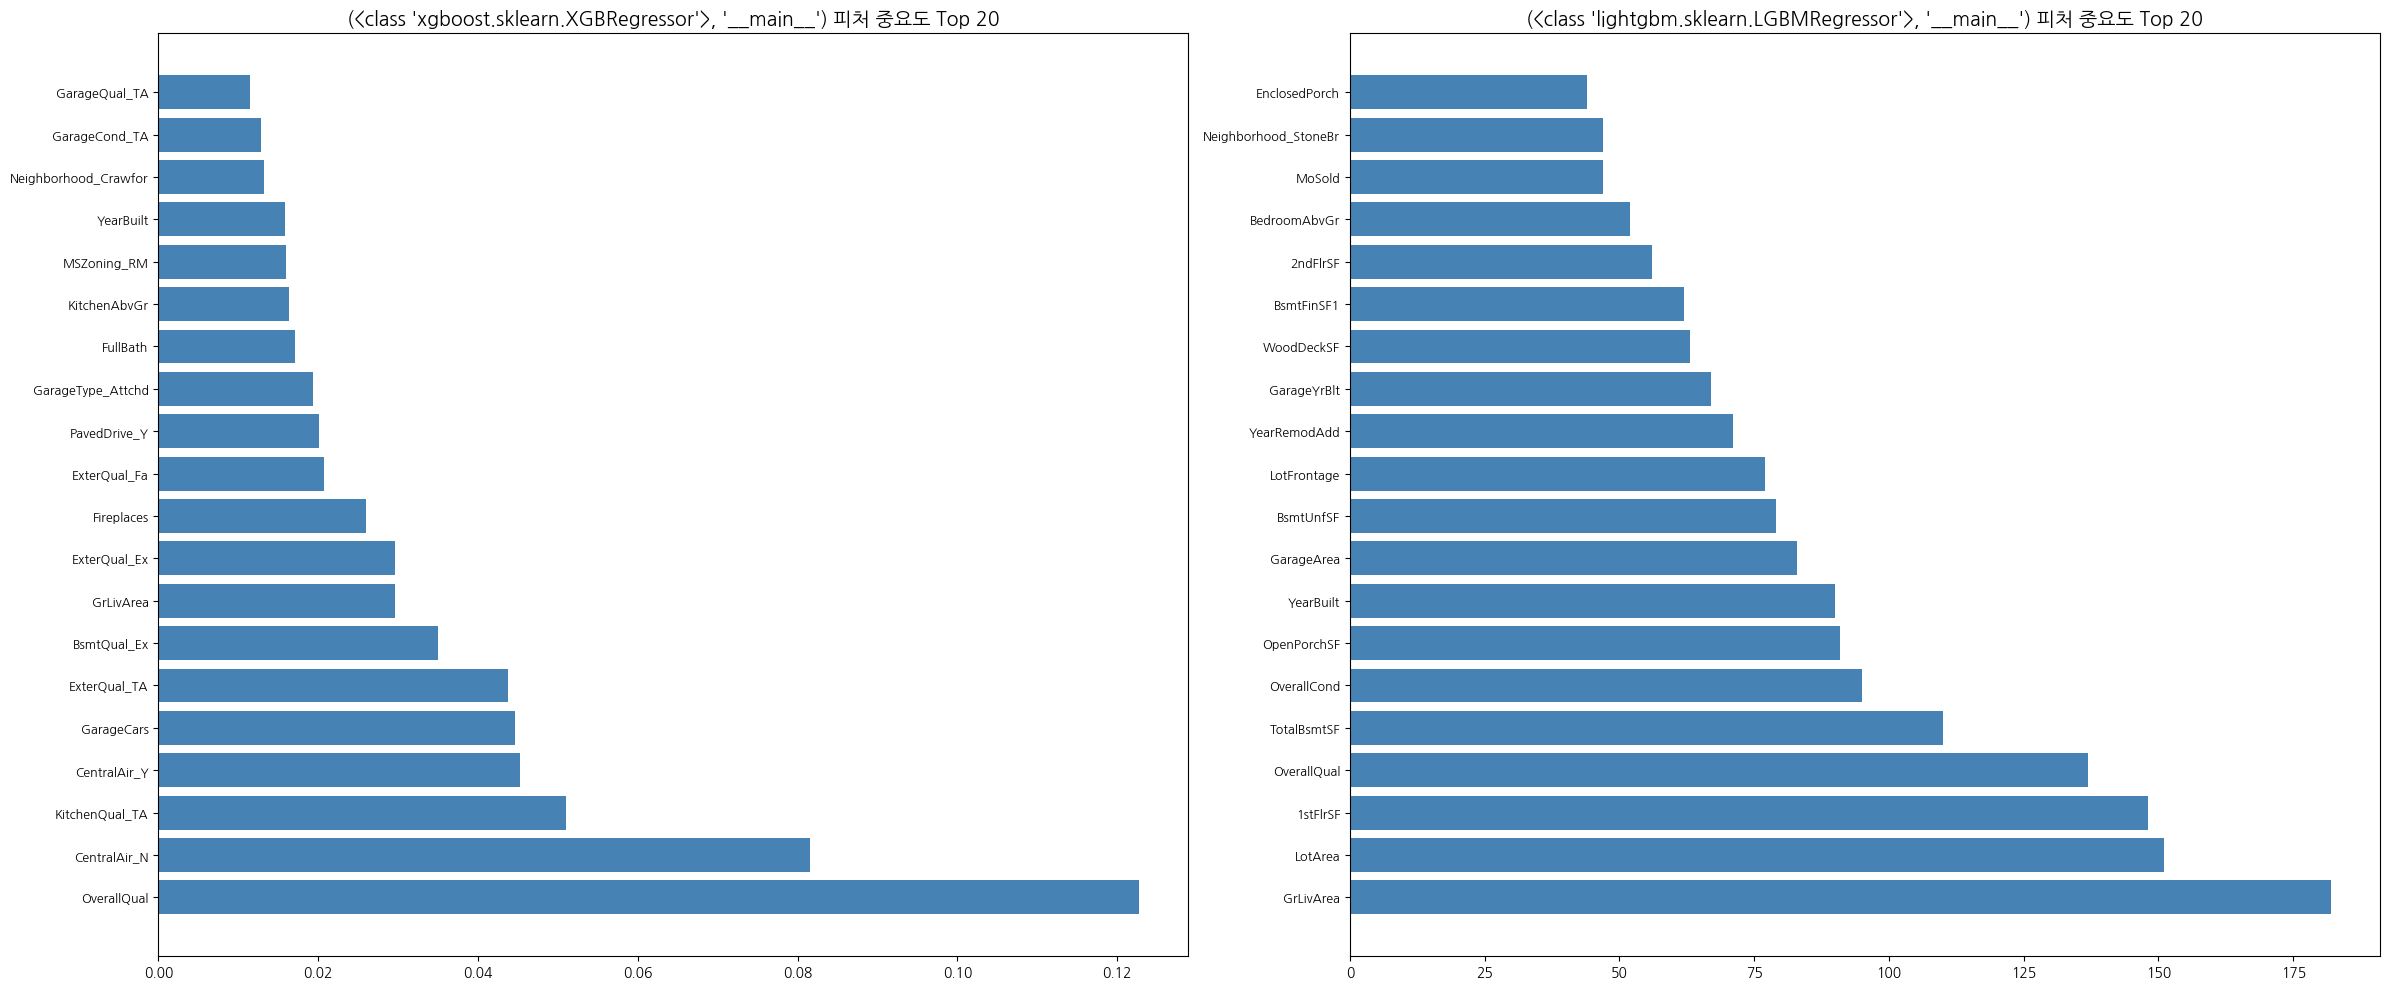

In [27]:
# 트리 모델 피처 중요도 (Feature Importance) 시각화
# 각 피처가 트리 분기점으로 사용된 횟수(split) 또는 분기로 인한 손실 감소량 (gain)을 기준으로 중요도 측정
# 어떤 피처가 예측에 많이 활용되는지 파악
def get_top_feature(model):

  ftr_imp = pd.Series(model.feature_importances_, index=X_features.columns) # 'feature_importance_' -> 'feature_importances_'로 수정
  return ftr_imp.sort_values(ascending=False)[:20] # 피처 중요도 상위 20개 추출

def visualize_ftr_importance(models):
  fig, axs = plt.subplots(figsize=(24, 10), nrows=1, ncols=2)
  for i, model in enumerate(models):
    ftr_top20 = get_top_feature(model)
    axs[i].set_title(f'{model.__class__,__name__} 피처 중요도 Top 20', size=14)
    axs[i].tick_params(axis='y', labelsize=9)
    axs[i].barh(ftr_top20.index, ftr_top20.values, color='steelblue') # 'steelblye' -> 'steelblue'로 수정
  fig.tight_layout()
  plt.show()

# 피처 중요도는 학습된 모델에서만 추출 가능
xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)
visualize_ftr_importance([xgb_reg, lgbm_reg])

## 회귀 모델 예측 결과 혼합 (Blending)
### 블렌딩(Blending)이란?
* 여러 모델의 예측값을 가중 평균으로 합산
* 단순하지만 효과적인 앙상블 기법

### 블렌딩이 효과적인 이유
* 서로 다른 모델은 서로 다른 패턴을 학습, 한 모델이 틀린 부분을 다른 모델이 보완
* 개별 모델보다 전체적으로 더 안정적이고 정확한 예측

### Ridge 40% + Lasso 60% 가중치 설정 이유
* Lasso가 피처 선택 효과로 더 깔끔한 예측

* 블렌딩은 이미 학습된 릿지 모델과 라쏘 모델의 예측값을 섞는 것이고 , 블렌딩은 다양한 모델의 장점을 활용하는 앙상블 기법
* 엘라스틱넷은 처음부터 L1과 L2 규제를 동시에 적용하여 새로운 하나의 모델을 만드는 것, 엘라스틱넷은 하나의 모델 내에서 규제를 효과적으로 사용하는 방법

In [29]:
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 예측을 테스트 세트에 대해 수행하여 y_test와 비교
ridge_pred = ridge_reg.predict(X_test)
lasso_pred = lasso_reg.predict(X_test)

# 가중 평균 혼합: Ridge 40% + Lasso 60%
pred_avg_test = 0.4 * ridge_pred + 0.6 * lasso_pred
preds = {
    '혼합 (Ridge 40% + Lasso 60%)': pred_avg_test,
    'Ridge': ridge_pred,
    'Lasso': lasso_pred
}
print('선형 모델 혼합 RMSE')
def get_rmses_pred(preds):
  for key, pred_value in preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred_value))
    print(f"{key} RMSE: {rmse:.4f}")

get_rmses_pred(preds)

선형 모델 혼합 RMSE
혼합 (Ridge 40% + Lasso 60%) RMSE: 0.1192
Ridge RMSE: 0.1226
Lasso RMSE: 0.1193


In [32]:
lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=4,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_lambda=10, # L2 규제 강도, reg_alpha (L1 규제)
    n_jobs=-1
)
lgbm_reg.fit(X_train, y_train)
lgbm_pred = lgbm_reg.predict(X_test)

# XGBoost 모델도 학습 후 예측값 생성
xgb_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)

#XGBoost 50 % + LightGBM 50% 동일 가중치
pred_blend_test = 0.5 * xgb_pred + 0.5 * lgbm_pred
preds = {
    '혼합 (XGBoost 50% + LightGBM 50%)': pred_blend_test, # Corrected variable name
    'XGBoost': xgb_pred,
    'LightGBM': lgbm_pred
}
print('트리 모델 혼합 RMSE')
get_rmses_pred(preds) # Corrected function name

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3158
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 169
[LightGBM] [Info] Start training from score 12.023289
트리 모델 혼합 RMSE
혼합 (XGBoost 50% + LightGBM 50%) RMSE: 0.1227
XGBoost RMSE: 0.1279
LightGBM RMSE: 0.1233


In [34]:
# 스태킹 앙상블 모델로 회귀 예측
# 블렌딩: 단순 가중 평균 -> 간단하지만 가중치를 수동 설정
# 스태킹: 메타 모델이 가중치 자동 학습 -> 더 정교하지만 복잡

def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
  kf = KFold(n_splits=n_folds, shuffle=False)
  meta_train_fold_pred = np.zeros((X_train_n.shape[0],1)) # 메타 학습셋: 학습 데이터 크기와 동일한 0 배열로 초기화
  meta_test_pred = np.zeros((X_test_n.shape[0], n_folds)) # 메타 테스트셋: 각 폴드별 테스트 예측 저장 (나중에 평균)
  print(model.__class__.__name__, '모델 시작')
  # 폴드별 학습/검증 분할
  for folder_cnt, (train_idx, valid_idx) in enumerate(kf.split(X_train_n)):
    X_tr = X_train_n[train_idx]
    y_tr = y_train_n[train_idx]
    X_va = X_train_n[valid_idx]

    model.fit(X_tr, y_tr)
    meta_train_fold_pred[valid_idx, :] = model.predict(X_va).reshape(-1,1) # 검증 폴드 예측 -> 메타 학습셋 해당 위치에
    meta_test_pred[:, folder_cnt] = model.predict(X_test_n) # 'predcit' -> 'predict' 수정

  meta_test_pred_mean = np.mean(meta_test_pred, axis=1).reshape(-1,1)
  return meta_train_fold_pred, meta_test_pred_mean # 'test_pred_mean' -> 'meta_test_pred_mean' 수정

#pandas DataFrame -> numpy ndarrary 변환
X_train_n = X_train.values
X_test_n = X_test.values
y_train_n = y_train.values

# 기반 모델 4개의 CV 예측 데이터 생성
# 각 모델이 5-Fold로 학습 -> 학습/테스트 메타 데이터 반환
ridge_tr, ridge_ts = get_stacking_base_datasets(ridge_reg, X_train_n, y_train_n, X_test_n, 5) # '=' 추가
lasso_tr, lasso_ts = get_stacking_base_datasets(lasso_reg, X_train_n, y_train_n, X_test_n, 5)
xgb_tr, xgb_ts = get_stacking_base_datasets(xgb_reg, X_train_n, y_train_n, X_test_n, 5)
lgbm_tr, lgbm_ts = get_stacking_base_datasets(lgbm_reg, X_train_n, y_train_n, X_test_n, 5)

Ridge 모델 시작
Lasso 모델 시작
XGBRegressor 모델 시작
LGBMRegressor 모델 시작
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2960
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 158
[LightGBM] [Info] Start training from score 12.024507
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2938
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 158
[LightGBM] [Info] Start training from score 12.023116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000875 seconds.
You can set `force_ro

In [36]:
# 메타 모델 입력 데이터 구성 및 최종 예측
Stack_final_X_train = np.concatenate(
    (ridge_tr, lasso_tr, xgb_tr, lgbm_tr), axis=1 #(N행, 4열) 행렬
)
Stack_final_X_test = np.concatenate(
    (ridge_ts, lasso_ts, xgb_ts, lgbm_ts), axis=1 #(N행, 4열) 행렬
)
meta_model_lasso = Lasso(alpha=0.0005)
meta_model_lasso.fit(Stack_final_X_train, y_train)
final = meta_model_lasso.predict(Stack_final_X_test)

rmse = np.sqrt(mean_squared_error(y_test, final))
print(f'\n스태킹 앙상블 최종 RMSE: {rmse:.4f}')


스태킹 앙상블 최종 RMSE: 0.1174
